In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
G = nx.Graph()


G.add_nodes_from(["A", "B", "N", "S", "L"])


G.add_edges_from([
    ("A", "B"),
    ("N", "S"),
    ("N", "L"),
    ("S", "L")
])

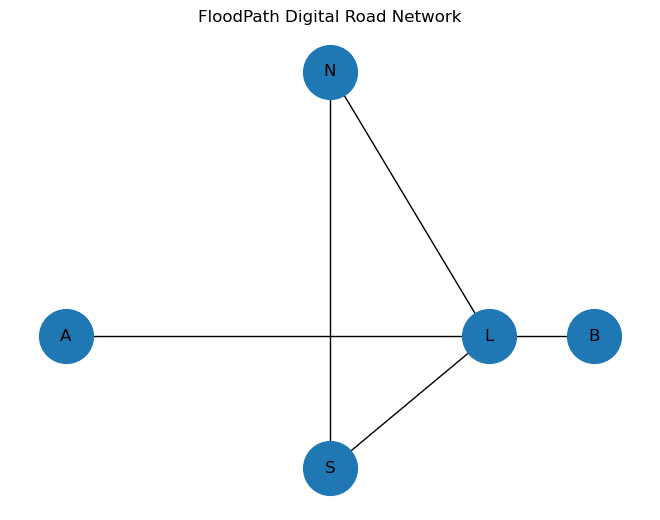

In [4]:
pos = {
    "A": (0, 1),
    "B": (5, 1),
    "N": (2.5, 3),
    "S": (2.5, 0),
    "L": (4, 1)
}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1500,
    font_size=12
)

plt.title("FloodPath Digital Road Network")
plt.savefig("road_network.png")
plt.show()

In [5]:
road_data = {
    ("A", "B"): {"distance": 2, "risk": "low"},
    ("N", "S"): {"distance": 4, "risk": "medium"},
    ("N", "L"): {"distance": 6, "risk": "high"},
    ("S", "L"): {"distance": 3, "risk": "low"}
}

In [6]:
risk_penalty = {
    "low": 1,
    "medium": 5,
    "high": 10
}

for road, data in road_data.items():
    distance = data["distance"]
    risk = data["risk"]

    score = distance + risk_penalty[risk]

    G[road[0]][road[1]]["weight"] = score

    print(
        road[0], "-", road[1],
        "| Distance:", distance, "km",
        "| Risk:", risk,
        "| Weighted Score:", score
    )

A - B | Distance: 2 km | Risk: low | Weighted Score: 3
N - S | Distance: 4 km | Risk: medium | Weighted Score: 9
N - L | Distance: 6 km | Risk: high | Weighted Score: 16
S - L | Distance: 3 km | Risk: low | Weighted Score: 4


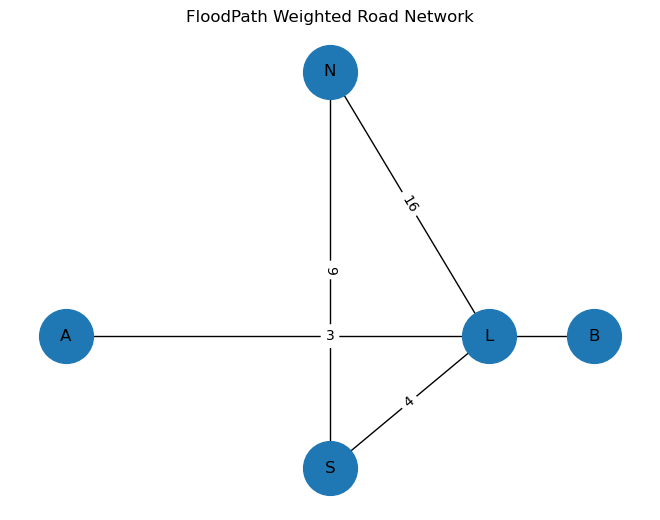

In [7]:
edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1500,
    font_size=12
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title("FloodPath Weighted Road Network")
plt.savefig("weighted_road_network.png")
plt.show()